<a href="https://colab.research.google.com/github/sunil5058/AI-ML/blob/main/Week_4_Workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**k-NN Algorithm:**

In [5]:
import pandas as pd
import numpy as np


# Load the Titanic dataset
data = pd.read_csv("/content/drive/MyDrive/Copy of Titanic-Dataset.csv")


# Drop all categorical columns except ’Survived’
categorical_columns = data.select_dtypes(include=['object']).columns
data = data.drop(columns=[col for col in categorical_columns if col != 'Survived'])


# Check for missing values
missing_info = data.isnull().sum() / len(data) * 100


# Handle missing values
for column in data.columns:
  if missing_info[column] > 10: # If more than 10% missing
        data[column].fillna(data[column].mean(), inplace=True)
  else: # If less than 10% missing
        data.dropna(subset=[column], inplace=True)


# Display cleaned data
print("Data after processing:\n", data.head())
print("\nMissing values after processing:\n", data.isnull().sum())

Data after processing:
    PassengerId  Survived  Pclass   Age  SibSp  Parch     Fare
0            1         0       3  22.0      1      0   7.2500
1            2         1       1  38.0      1      0  71.2833
2            3         1       3  26.0      0      0   7.9250
3            4         1       1  35.0      1      0  53.1000
4            5         0       3  35.0      0      0   8.0500

Missing values after processing:
 PassengerId    0
Survived       0
Pclass         0
Age            0
SibSp          0
Parch          0
Fare           0
dtype: int64


/tmp/ipython-input-1230549106.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[column].fillna(data[column].mean(), inplace=True)


In [6]:
# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time


In [7]:
# Load diabetes dataset
data = pd.read_csv("/content/drive/MyDrive/Copy of diabetes_.csv")

# Display first 5 rows
print("First 5 rows of the dataset:\n", data.head())

# Basic info about dataset
print("\nDataset Info:")
print(data.info())

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Summary statistics
print("\nSummary statistics:\n", data.describe())


First 5 rows of the dataset:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null 

In [8]:
# Columns that can't have zero values (except target)
cols_with_invalid_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Replace zeros with column mean
for col in cols_with_invalid_zeros:
    data[col] = data[col].replace(0, data[col].mean())

print("\nAfter handling invalid zeros:")
print(data.isnull().sum())



After handling invalid zeros:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [9]:
# Separate features and target
X = data.drop(columns=["Outcome"]).values
y = data["Outcome"].values

# Custom train-test split function
def train_test_split_scratch(X, y, test_size=0.3, random_seed=42):
    np.random.seed(random_seed)
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    test_size_int = int(len(X) * test_size)
    test_indices = indices[:test_size_int]
    train_indices = indices[test_size_int:]
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]
    return X_train, X_test, y_train, y_test

# Split dataset
X_train, X_test, y_train, y_test = train_test_split_scratch(X, y, test_size=0.3)
print("Train-Test Split:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


Train-Test Split:
X_train shape: (538, 8)
X_test shape: (230, 8)
y_train shape: (538,)
y_test shape: (230,)


In [10]:
def euclidean_distance(point1, point2):
    if point1.shape != point2.shape:
        raise ValueError("Points must have the same dimensions")
    return np.sqrt(np.sum((point1 - point2) ** 2))

# Test case
assert np.isclose(euclidean_distance(np.array([3,4]), np.array([0,0])), 5.0)
print("Euclidean distance function works correctly!")


Euclidean distance function works correctly!


In [11]:
# Predict class for a single query
def knn_predict_single(query, X_train, y_train, k=3):
    distances = [euclidean_distance(query, x) for x in X_train]
    sorted_indices = np.argsort(distances)
    nearest_labels = y_train[sorted_indices[:k]]
    prediction = np.bincount(nearest_labels).argmax()
    return prediction

# Predict for all test samples
def knn_predict(X_test, X_train, y_train, k=3):
    return np.array([knn_predict_single(x, X_train, y_train, k) for x in X_test])


In [12]:
def compute_accuracy(y_true, y_pred):
    return (np.sum(y_true == y_pred) / len(y_true)) * 100


In [13]:
k = 3
predictions = knn_predict(X_test, X_train, y_train, k=k)
accuracy = compute_accuracy(y_test, predictions)
print(f"Accuracy of KNN with k={k} on test set: {accuracy:.2f}%")


Accuracy of KNN with k=3 on test set: 70.43%


In [14]:
# Standardize features
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std


In [15]:
pred_scaled = knn_predict(X_test_scaled, X_train_scaled, y_train, k=k)
accuracy_scaled = compute_accuracy(y_test, pred_scaled)

print(f"Accuracy on original data: {accuracy:.2f}%")
print(f"Accuracy on scaled data: {accuracy_scaled:.2f}%")


Accuracy on original data: 70.43%
Accuracy on scaled data: 70.43%


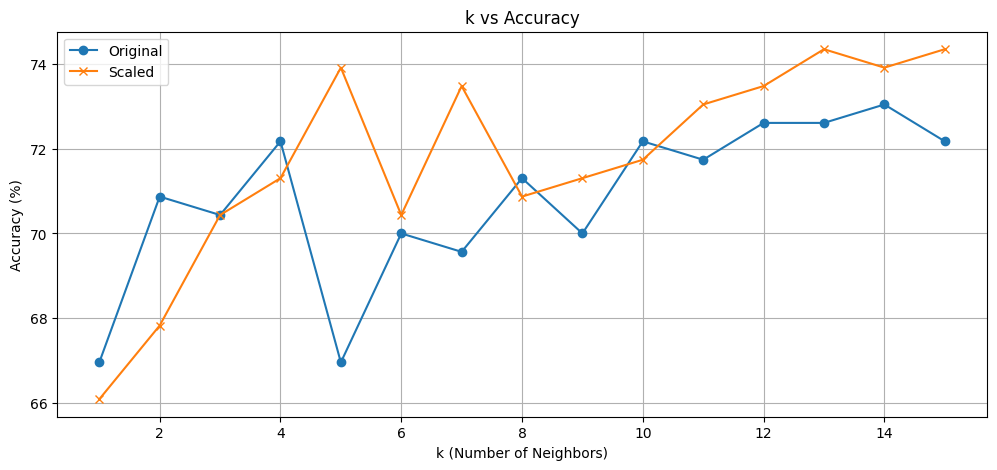

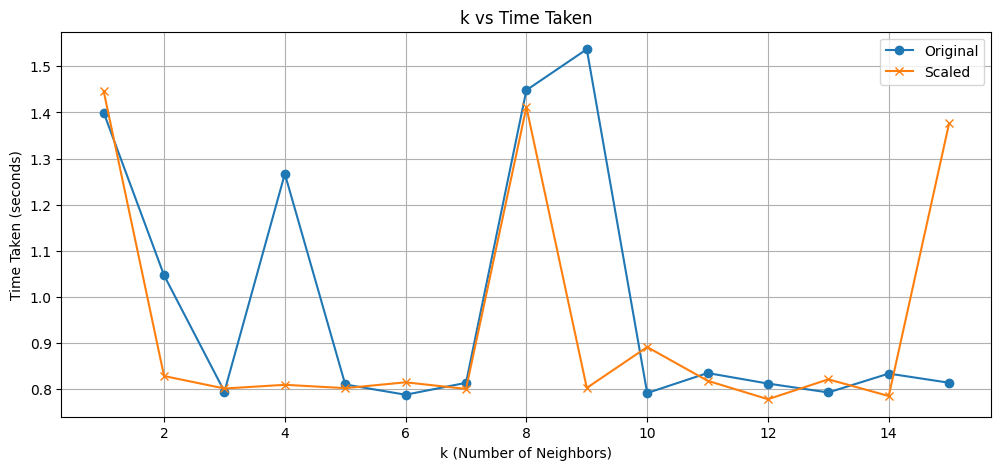

In [16]:
k_values = range(1, 16)
accuracy_original = []
accuracy_scaled = []
time_original = []
time_scaled = []

for k in k_values:
    # Original
    start_time = time.time()
    pred_orig = knn_predict(X_test, X_train, y_train, k=k)
    time_original.append(time.time() - start_time)
    accuracy_original.append(compute_accuracy(y_test, pred_orig))

    # Scaled
    start_time = time.time()
    pred_scl = knn_predict(X_test_scaled, X_train_scaled, y_train, k=k)
    time_scaled.append(time.time() - start_time)
    accuracy_scaled.append(compute_accuracy(y_test, pred_scl))

# Plot Accuracy
plt.figure(figsize=(12,5))
plt.plot(k_values, accuracy_original, marker='o', label='Original')
plt.plot(k_values, accuracy_scaled, marker='x', label='Scaled')
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Accuracy (%)")
plt.title("k vs Accuracy")
plt.grid(True)
plt.legend()
plt.show()

# Plot Time Taken
plt.figure(figsize=(12,5))
plt.plot(k_values, time_original, marker='o', label='Original')
plt.plot(k_values, time_scaled, marker='x', label='Scaled')
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Time Taken (seconds)")
plt.title("k vs Time Taken")
plt.grid(True)
plt.legend()
plt.show()
